### Day5 Goals
- Fill imd_band with respective region avg for a given outcome
- Matching all withdrawn date with a withdrawn result
- Seperate Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

In [2]:
reg  = pd.read_csv('anonymisedData/studentRegistration.csv')
info = pd.read_csv('anonymisedData/studentInfo.csv')
vle  = pd.read_csv('anonymisedData/vle.csv')

course = pd.read_csv('anonymisedData/courses.csv')

In [3]:
svle = pd.read_csv('anonymisedData/studentVle.csv')

In [4]:
info.shape

(32593, 12)

In [5]:
imdo = {
    '0-10%':0, '10-20':1, '20-30%':2, '30-40%':3, '40-50%':4,
    '50-60%':5, '60-70%':6, '70-80%':7, '80-90%':8, '90-100%':9
}

info["imd_band_enc"] = info["imd_band"].map(imdo)

In [6]:
info["imd_band_enc"] = (
    info["imd_band_enc"]
    .fillna(
        info.groupby(["region", "final_result"])["imd_band_enc"]
            .transform("mean")
    )
)

In [7]:
info["imd_band_enc"] = info["imd_band_enc"].round().astype(int)

In [8]:
info["imd_band_enc"].isna().sum()

0

In [9]:
info.shape

(32593, 13)

<Axes: >

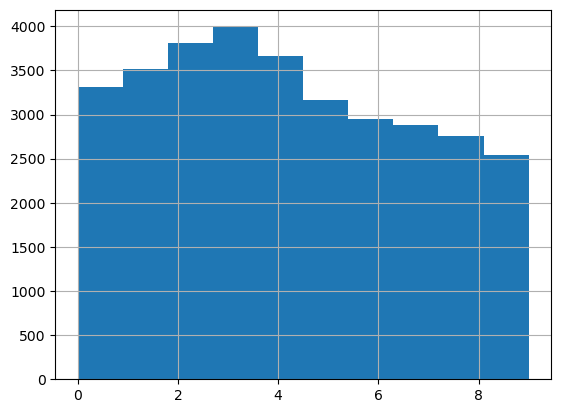

In [10]:
info["imd_band_enc"].hist()

In [11]:
reg['date_unregistration'].value_counts().sum()

10072

In [12]:
reg[reg.duplicated()]

,code_module,code_presentation,id_student,date_registration,date_unregistration


In [13]:
info[info.duplicated()]

,code_module,code_presentation,id_student,gender,region,highest_education,imd_band,age_band,num_of_prev_attempts,studied_credits,disability,final_result,imd_band_enc


In [14]:
info[info["id_student"].duplicated()]

,code_module,code_presentation,id_student,gender,region,highest_education,imd_band,age_band,num_of_prev_attempts,studied_credits,disability,final_result,imd_band_enc
395,AAA,2014J,65002,F,East Anglian Region,A Level or Equivalent,70-80%,0-35,1,60,N,Fail,7
403,AAA,2014J,94961,M,South Region,Lower Than A Level,70-80%,35-55,1,60,N,Pass,7
415,AAA,2014J,129955,M,West Midlands Region,A Level or Equivalent,50-60%,0-35,1,60,N,Withdrawn,5
422,AAA,2014J,135335,F,East Anglian Region,Lower Than A Level,20-30%,0-35,1,120,N,Withdrawn,2
423,AAA,2014J,135400,F,South East Region,Lower Than A Level,90-100%,35-55,1,60,Y,Pass,9
...,...,...,...,...,...,...,...,...,...,...,...,...,...
31964,GGG,2014J,600320,F,West Midlands Region,Lower Than A Level,40-50%,35-55,1,30,Y,Pass,4
31966,GGG,2014J,603585,M,West Midlands Region,Lower Than A Level,30-40%,35-55,1,30,N,Fail,3
31994,GGG,2014J,624767,F,London Region,A Level or Equivalent,90-100%,35-55,1,30,N,Distinction,9
32003,GGG,2014J,627812,F,Yorkshire Region,Lower Than A Level,60-70%,0-35,1,30,N,Distinction,6


In [15]:
info["final_result"].value_counts()

final_result
Pass           12361
Withdrawn      10156
Fail            7052
Distinction     3024
Name: count, dtype: int64

In [16]:
info=info.merge(reg,on=["id_student","code_module","code_presentation"])

In [17]:
info.shape

(32593, 15)

In [18]:
info[info.duplicated()]

,code_module,code_presentation,id_student,gender,region,highest_education,imd_band,age_band,num_of_prev_attempts,studied_credits,disability,final_result,imd_band_enc,date_registration,date_unregistration


In [19]:
info[info["id_student"]==65002]

,code_module,code_presentation,id_student,gender,region,highest_education,imd_band,age_band,num_of_prev_attempts,studied_credits,disability,final_result,imd_band_enc,date_registration,date_unregistration
15,AAA,2013J,65002,F,East Anglian Region,A Level or Equivalent,70-80%,0-35,0,60,N,Withdrawn,7,-180.0,96.0
395,AAA,2014J,65002,F,East Anglian Region,A Level or Equivalent,70-80%,0-35,1,60,N,Fail,7,-144.0,NaN


In [20]:
info.loc[
    (info["final_result"] == "Withdrawn") &
    (info["date_unregistration"].isna()),
    ["code_module","code_presentation","id_student","final_result", "date_unregistration"]
]

,code_module,code_presentation,id_student,final_result,date_unregistration
6315,BBB,2014B,2512349,Withdrawn,NaN
6484,BBB,2014J,271047,Withdrawn,NaN
6601,BBB,2014J,417978,Withdrawn,NaN
7247,BBB,2014J,636660,Withdrawn,NaN
7410,BBB,2014J,647876,Withdrawn,NaN
...,...,...,...,...,...
29978,FFF,2014J,2398260,Withdrawn,NaN
30032,FFF,2014J,2622634,Withdrawn,NaN
30562,GGG,2013J,590248,Withdrawn,NaN
32149,GGG,2014J,646891,Withdrawn,NaN


In [21]:
info[info["id_student"]==271047]

,code_module,code_presentation,id_student,gender,region,highest_education,imd_band,age_band,num_of_prev_attempts,studied_credits,disability,final_result,imd_band_enc,date_registration,date_unregistration
6484,BBB,2014J,271047,F,South West Region,Lower Than A Level,90-100%,0-35,0,60,N,Withdrawn,9,-25.0,NaN


In [22]:
mask = (
    (info["final_result"] == "Withdrawn") &
    (info["date_unregistration"].isna())
)

fill_value = (
    info.loc[
        (info["final_result"] == "Withdrawn") &
        (~info["date_unregistration"].isna()),
        "date_unregistration"
    ].median()      # or .mean()
)

info.loc[mask, "date_unregistration"] = fill_value

In [23]:
info.loc[
    (info["final_result"] == "Withdrawn") &
    (info["date_unregistration"].isna()),
    ["code_module","code_presentation","id_student","final_result", "date_unregistration"]
]

,code_module,code_presentation,id_student,final_result,date_unregistration


In [24]:
info = info[(info["code_module"] == "BBB") &(info["code_presentation"] == "2014J")]

In [25]:
svle['week'] = (svle['date'] // 7)+1

In [26]:
a = svle[['week','date']]
a[a['date']==0]

,week,date
10847,1,0
10848,1,0
10849,1,0
10850,1,0
10851,1,0
...,...,...
10546559,1,0
10546560,1,0
10546561,1,0
10546562,1,0


In [27]:
for w in [1, 2, 3]:
    wk = (svle[svle['week'] == w].groupby(['id_student', 'code_module', 'code_presentation'])['sum_click'].sum().rename(f'clicks_week{w}'))
    info = info.merge(wk, on=['id_student', 'code_module', 'code_presentation'], how='left')
    info[f'clicks_week{w}'] = info[f'clicks_week{w}'].fillna(0).astype(int)

In [28]:
info[['id_student','clicks_week1','clicks_week2','clicks_week3']]

,id_student,clicks_week1,clicks_week2,clicks_week3
0,26315,144,1,70
1,26734,52,26,12
2,32327,79,0,14
3,32930,0,0,50
4,34431,0,0,0
...,...,...,...,...
2287,2692969,67,63,95
2288,2694919,1,0,54
2289,2698577,0,0,49
2290,2698588,9,72,18


In [29]:
info['click_trend'] = info['clicks_week3'] - info['clicks_week1']

In [30]:
info=info.merge(course,  on=['code_module','code_presentation'], how='left')
info

,code_module,code_presentation,id_student,gender,region,highest_education,imd_band,age_band,num_of_prev_attempts,studied_credits,disability,final_result,imd_band_enc,date_registration,date_unregistration,clicks_week1,clicks_week2,clicks_week3,click_trend,module_presentation_length
0,BBB,2014J,26315,F,East Anglian Region,Lower Than A Level,60-70%,35-55,1,60,N,Pass,6,-92.0,NaN,144,1,70,-74,262
1,BBB,2014J,26734,M,South West Region,A Level or Equivalent,20-30%,0-35,0,90,Y,Fail,2,-101.0,NaN,52,26,12,-40,262
2,BBB,2014J,32327,F,South West Region,Lower Than A Level,20-30%,0-35,2,60,N,Withdrawn,2,-92.0,121.0,79,0,14,-65,262
3,BBB,2014J,32930,F,South Region,A Level or Equivalent,40-50%,35-55,0,60,N,Pass,4,-35.0,NaN,0,0,50,50,262
4,BBB,2014J,34431,F,Yorkshire Region,Lower Than A Level,70-80%,0-35,1,60,N,Withdrawn,7,-36.0,12.0,0,0,0,0,262
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2287,BBB,2014J,2692969,F,Scotland,HE Qualification,80-90%,35-55,0,75,N,Pass,8,-88.0,NaN,67,63,95,28,262
2288,BBB,2014J,2694919,F,East Anglian Region,Lower Than A Level,60-70%,35-55,0,120,Y,Pass,6,-127.0,NaN,1,0,54,53,262
2289,BBB,2014J,2698577,F,Wales,Lower Than A Level,50-60%,35-55,0,60,N,Fail,5,16.0,NaN,0,0,49,49,262
2290,BBB,2014J,2698588,F,Yorkshire Region,HE Qualification,30-40%,0-35,0,120,N,Distinction,3,4.0,NaN,9,72,18,9,262


In [31]:
last_click = svle.groupby(['id_student', 'code_module', 'code_presentation'])['date'].max().rename('last_click_day')
info = info.merge(last_click, on=['id_student', 'code_module', 'code_presentation'], how='left')
info

,code_module,code_presentation,id_student,gender,region,highest_education,imd_band,age_band,num_of_prev_attempts,studied_credits,...,final_result,imd_band_enc,date_registration,date_unregistration,clicks_week1,clicks_week2,clicks_week3,click_trend,module_presentation_length,last_click_day
0,BBB,2014J,26315,F,East Anglian Region,Lower Than A Level,60-70%,35-55,1,60,...,Pass,6,-92.0,NaN,144,1,70,-74,262,257.0
1,BBB,2014J,26734,M,South West Region,A Level or Equivalent,20-30%,0-35,0,90,...,Fail,2,-101.0,NaN,52,26,12,-40,262,133.0
2,BBB,2014J,32327,F,South West Region,Lower Than A Level,20-30%,0-35,2,60,...,Withdrawn,2,-92.0,121.0,79,0,14,-65,262,102.0
3,BBB,2014J,32930,F,South Region,A Level or Equivalent,40-50%,35-55,0,60,...,Pass,4,-35.0,NaN,0,0,50,50,262,231.0
4,BBB,2014J,34431,F,Yorkshire Region,Lower Than A Level,70-80%,0-35,1,60,...,Withdrawn,7,-36.0,12.0,0,0,0,0,262,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2287,BBB,2014J,2692969,F,Scotland,HE Qualification,80-90%,35-55,0,75,...,Pass,8,-88.0,NaN,67,63,95,28,262,262.0
2288,BBB,2014J,2694919,F,East Anglian Region,Lower Than A Level,60-70%,35-55,0,120,...,Pass,6,-127.0,NaN,1,0,54,53,262,239.0
2289,BBB,2014J,2698577,F,Wales,Lower Than A Level,50-60%,35-55,0,60,...,Fail,5,16.0,NaN,0,0,49,49,262,235.0
2290,BBB,2014J,2698588,F,Yorkshire Region,HE Qualification,30-40%,0-35,0,120,...,Distinction,3,4.0,NaN,9,72,18,9,262,258.0


In [32]:
info['days_since_last_click'] = info['module_presentation_length']-info['last_click_day']
info

,code_module,code_presentation,id_student,gender,region,highest_education,imd_band,age_band,num_of_prev_attempts,studied_credits,...,imd_band_enc,date_registration,date_unregistration,clicks_week1,clicks_week2,clicks_week3,click_trend,module_presentation_length,last_click_day,days_since_last_click
0,BBB,2014J,26315,F,East Anglian Region,Lower Than A Level,60-70%,35-55,1,60,...,6,-92.0,NaN,144,1,70,-74,262,257.0,5.0
1,BBB,2014J,26734,M,South West Region,A Level or Equivalent,20-30%,0-35,0,90,...,2,-101.0,NaN,52,26,12,-40,262,133.0,129.0
2,BBB,2014J,32327,F,South West Region,Lower Than A Level,20-30%,0-35,2,60,...,2,-92.0,121.0,79,0,14,-65,262,102.0,160.0
3,BBB,2014J,32930,F,South Region,A Level or Equivalent,40-50%,35-55,0,60,...,4,-35.0,NaN,0,0,50,50,262,231.0,31.0
4,BBB,2014J,34431,F,Yorkshire Region,Lower Than A Level,70-80%,0-35,1,60,...,7,-36.0,12.0,0,0,0,0,262,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2287,BBB,2014J,2692969,F,Scotland,HE Qualification,80-90%,35-55,0,75,...,8,-88.0,NaN,67,63,95,28,262,262.0,0.0
2288,BBB,2014J,2694919,F,East Anglian Region,Lower Than A Level,60-70%,35-55,0,120,...,6,-127.0,NaN,1,0,54,53,262,239.0,23.0
2289,BBB,2014J,2698577,F,Wales,Lower Than A Level,50-60%,35-55,0,60,...,5,16.0,NaN,0,0,49,49,262,235.0,27.0
2290,BBB,2014J,2698588,F,Yorkshire Region,HE Qualification,30-40%,0-35,0,120,...,3,4.0,NaN,9,72,18,9,262,258.0,4.0


In [33]:
info['days_since_last_click'].describe()

count    1921.000000
mean       77.835502
std        85.919494
min         0.000000
25%        19.000000
50%        27.000000
75%       136.000000
max       271.000000
Name: days_since_last_click, dtype: float64

In [34]:
unique_res = svle.groupby(['id_student', 'code_module', 'code_presentation'])['id_site'].nunique().rename('unique_resources')
info = info.merge(unique_res, on=['id_student', 'code_module', 'code_presentation'], how='left')
info['unique_resources'] = info['unique_resources'].fillna(0).astype(int)
info

,code_module,code_presentation,id_student,gender,region,highest_education,imd_band,age_band,num_of_prev_attempts,studied_credits,...,date_registration,date_unregistration,clicks_week1,clicks_week2,clicks_week3,click_trend,module_presentation_length,last_click_day,days_since_last_click,unique_resources
0,BBB,2014J,26315,F,East Anglian Region,Lower Than A Level,60-70%,35-55,1,60,...,-92.0,NaN,144,1,70,-74,262,257.0,5.0,103
1,BBB,2014J,26734,M,South West Region,A Level or Equivalent,20-30%,0-35,0,90,...,-101.0,NaN,52,26,12,-40,262,133.0,129.0,26
2,BBB,2014J,32327,F,South West Region,Lower Than A Level,20-30%,0-35,2,60,...,-92.0,121.0,79,0,14,-65,262,102.0,160.0,51
3,BBB,2014J,32930,F,South Region,A Level or Equivalent,40-50%,35-55,0,60,...,-35.0,NaN,0,0,50,50,262,231.0,31.0,55
4,BBB,2014J,34431,F,Yorkshire Region,Lower Than A Level,70-80%,0-35,1,60,...,-36.0,12.0,0,0,0,0,262,NaN,NaN,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2287,BBB,2014J,2692969,F,Scotland,HE Qualification,80-90%,35-55,0,75,...,-88.0,NaN,67,63,95,28,262,262.0,0.0,81
2288,BBB,2014J,2694919,F,East Anglian Region,Lower Than A Level,60-70%,35-55,0,120,...,-127.0,NaN,1,0,54,53,262,239.0,23.0,51
2289,BBB,2014J,2698577,F,Wales,Lower Than A Level,50-60%,35-55,0,60,...,16.0,NaN,0,0,49,49,262,235.0,27.0,69
2290,BBB,2014J,2698588,F,Yorkshire Region,HE Qualification,30-40%,0-35,0,120,...,4.0,NaN,9,72,18,9,262,258.0,4.0,56


In [35]:
info[['clicks_week1','clicks_week2','clicks_week3','click_trend','days_since_last_click','unique_resources']].describe().round(3)

,clicks_week1,clicks_week2,clicks_week3,click_trend,days_since_last_click,unique_resources
count,2292.000,2292.000,2292.000,2292.000,1921.000,2292.000
mean,33.278,25.533,25.817,-7.461,77.836,47.400
std,57.323,43.371,41.650,57.356,85.919,36.461
min,0.000,0.000,0.000,-722.000,0.000,0.000
25%,0.000,0.000,0.000,-23.000,19.000,12.000
50%,13.000,7.000,8.000,0.000,27.000,46.000
75%,45.000,35.000,37.000,8.000,136.000,79.000
max,775.000,478.000,373.000,330.000,271.000,158.000


In [36]:
info['days_since_last_click']=info['days_since_last_click'].fillna(info['module_presentation_length']).astype(int)

In [37]:
info[['clicks_week1','clicks_week2','clicks_week3','click_trend','days_since_last_click','unique_resources']].describe().round(3)

,clicks_week1,clicks_week2,clicks_week3,click_trend,days_since_last_click,unique_resources
count,2292.000,2292.000,2292.000,2292.000,2292.000,2292.000
mean,33.278,25.533,25.817,-7.461,107.646,47.400
std,57.323,43.371,41.650,57.356,103.875,36.461
min,0.000,0.000,0.000,-722.000,0.000,0.000
25%,0.000,0.000,0.000,-23.000,23.000,12.000
50%,13.000,7.000,8.000,0.000,42.000,46.000
75%,45.000,35.000,37.000,8.000,233.000,79.000
max,775.000,478.000,373.000,330.000,271.000,158.000


In [38]:
info.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2292 entries, 0 to 2291
Data columns (total 23 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   code_module                 2292 non-null   object 
 1   code_presentation           2292 non-null   object 
 2   id_student                  2292 non-null   int64  
 3   gender                      2292 non-null   object 
 4   region                      2292 non-null   object 
 5   highest_education           2292 non-null   object 
 6   imd_band                    2279 non-null   object 
 7   age_band                    2292 non-null   object 
 8   num_of_prev_attempts        2292 non-null   int64  
 9   studied_credits             2292 non-null   int64  
 10  disability                  2292 non-null   object 
 11  final_result                2292 non-null   object 
 12  imd_band_enc                2292 non-null   int32  
 13  date_registration           2291 

In [39]:
info['registered_late'] = (info['date_registration'] > 0).astype(int)
info['unregistered_early'] = (
    info['date_unregistration'].notna() &
    (info['date_unregistration'] < info['module_presentation_length'])
).astype(int)

In [40]:
info

,code_module,code_presentation,id_student,gender,region,highest_education,imd_band,age_band,num_of_prev_attempts,studied_credits,...,clicks_week1,clicks_week2,clicks_week3,click_trend,module_presentation_length,last_click_day,days_since_last_click,unique_resources,registered_late,unregistered_early
0,BBB,2014J,26315,F,East Anglian Region,Lower Than A Level,60-70%,35-55,1,60,...,144,1,70,-74,262,257.0,5,103,0,0
1,BBB,2014J,26734,M,South West Region,A Level or Equivalent,20-30%,0-35,0,90,...,52,26,12,-40,262,133.0,129,26,0,0
2,BBB,2014J,32327,F,South West Region,Lower Than A Level,20-30%,0-35,2,60,...,79,0,14,-65,262,102.0,160,51,0,1
3,BBB,2014J,32930,F,South Region,A Level or Equivalent,40-50%,35-55,0,60,...,0,0,50,50,262,231.0,31,55,0,0
4,BBB,2014J,34431,F,Yorkshire Region,Lower Than A Level,70-80%,0-35,1,60,...,0,0,0,0,262,NaN,262,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2287,BBB,2014J,2692969,F,Scotland,HE Qualification,80-90%,35-55,0,75,...,67,63,95,28,262,262.0,0,81,0,0
2288,BBB,2014J,2694919,F,East Anglian Region,Lower Than A Level,60-70%,35-55,0,120,...,1,0,54,53,262,239.0,23,51,0,0
2289,BBB,2014J,2698577,F,Wales,Lower Than A Level,50-60%,35-55,0,60,...,0,0,49,49,262,235.0,27,69,1,0
2290,BBB,2014J,2698588,F,Yorkshire Region,HE Qualification,30-40%,0-35,0,120,...,9,72,18,9,262,258.0,4,56,1,0


In [41]:
info.drop(columns=['date_registration', 'date_unregistration'], inplace=True)

In [42]:
eduo = {'No Formal quals': 0, 'Lower Than A Level': 1,
             'A Level or Equivalent': 2, 'HE Qualification': 3,
             'Post Graduate Qualification': 4}
info['education_enc'] = info['highest_education'].map(eduo)

In [43]:
ageo = {'0-35':1,'35-55':2,'55<=':3}
info['age_enc'] = info['age_band'].map(ageo).astype(int)

In [44]:
reso = {'Pass': 0, 'Distinction': 0, 'Fail': 1, 'Withdrawn': 1}
info['at_risk'] = info['final_result'].map(reso)

In [45]:
engineered= info[["gender","region","num_of_prev_attempts","studied_credits",
                  "disability","clicks_week1","clicks_week2","clicks_week3",
                  "click_trend","module_presentation_length","last_click_day",
                  "days_since_last_click","unique_resources","registered_late",
                  "unregistered_early","imd_band_enc","education_enc","age_enc",
                  "at_risk"]]

In [46]:
e2 = pd.get_dummies(engineered,dtype=int)

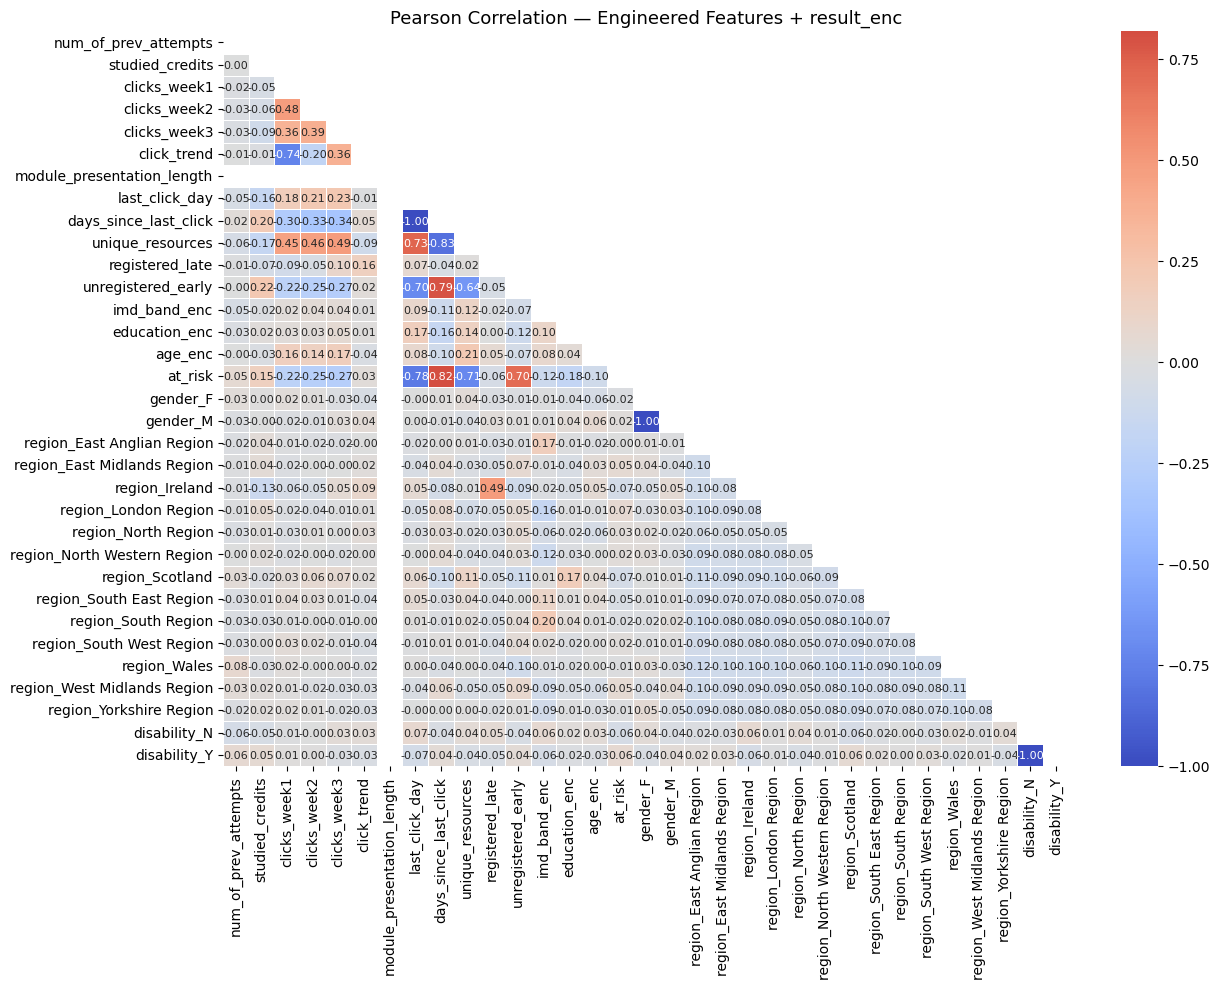

In [47]:
corr_df = e2.corr()
mask    = np.triu(np.ones_like(corr_df, dtype=bool))

fig, ax = plt.subplots(figsize=(13, 10))
sns.heatmap(corr_df, mask=mask, annot=True, fmt='.2f',
            cmap='coolwarm', center=0, linewidths=0.5,
            annot_kws={'size': 8}, ax=ax)
ax.set_title('Pearson Correlation — Engineered Features + result_enc', fontsize=13)
plt.tight_layout()
plt.show()

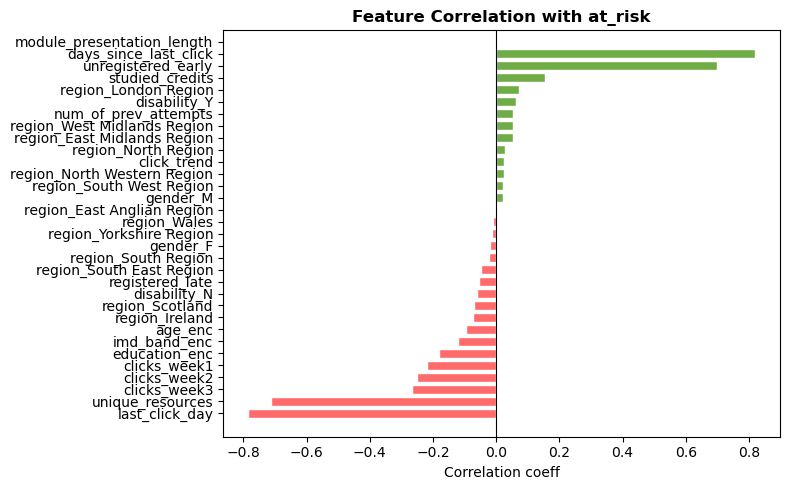


Correlation values:


,at_risk
last_click_day,-0.784
unique_resources,-0.712
clicks_week3,-0.267
clicks_week2,-0.251
clicks_week1,-0.220
education_enc,-0.180
imd_band_enc,-0.120
age_enc,-0.096
region_Ireland,-0.073
region_Scotland,-0.069


In [48]:
target_corr = e2.corr()['at_risk'].drop('at_risk').sort_values()

colors = ['#FF6B6B' if v < 0 else '#70AD47' for v in target_corr.values]
fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(target_corr.index, target_corr.values, color=colors, edgecolor='white')
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Feature Correlation with at_risk', fontsize=12, fontweight='bold')
ax.set_xlabel('Correlation coeff')
plt.tight_layout()
plt.show()

print('\nCorrelation values:')
display(target_corr.round(3).to_frame())

In [49]:
e2= e2.drop(columns=["last_click_day"])

In [50]:
e2.to_csv('engine2.csv', index=False)